In [1]:
# ============================================================================
# CELL 1: Imports
# ============================================================================
import torch
import torch.nn as nn
import numpy as np
import random
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import roc_curve, auc

import sys
import site
user_site = site.USER_SITE
me0_src = '/eos/home-i01/k/kkeshav/SWAN_projects/me0_v2/ME0SegReco/src'
for path in [user_site, me0_src]:
    if path not in sys.path:
        sys.path.insert(0, path)

from me0.data.datasets.image import ME0DigiImageDataset
from me0.modules.cnn.model import ME0SegCNN3d
from me0.losses import ME0BCELoss

torch.set_num_threads(5)
print("✓ Imports complete")

✓ Imports complete


In [2]:
# ============================================================================
# CELL 2: Reproducibility
# ============================================================================
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [3]:
# ============================================================================
# CELL 3: Device Setup
# ============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:

# ============================================================================
# CELL 4: Dataset and DataLoaders (70/15/15 split)
# ============================================================================
DATA_FILE   = '../data/step4_0.h5'
MODEL_PATH  = 'best_cnn_model.pt'   # <-- single source of truth for save/load

dataset = ME0DigiImageDataset(
    file=DATA_FILE,
    features={
        'cls': {'min': 1, 'max': 384},
        'bx':  {'min': -3, 'max': 3},
    },
    get_central_bx=True,
)

total_size = len(dataset)
train_size = int(0.70 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

print(f"\nDataset split (70/15/15):")
print(f"  Total: {total_size:,}")
print(f"  Train: {train_size:,} (70%)")
print(f"  Val:   {val_size:,} (15%)")
print(f"  Test:  {test_size:,} (15%)")

train_indices = list(range(0, train_size))
val_indices   = list(range(train_size, train_size + val_size))
test_indices  = list(range(train_size + val_size, total_size))

train_subset = Subset(dataset, train_indices)
val_subset   = Subset(dataset, val_indices)
test_subset  = Subset(dataset, test_indices)

batch_size   = 128
train_loader = DataLoader(train_subset, collate_fn=dataset.collate,
                          shuffle=True,  drop_last=True, batch_size=batch_size)
val_loader   = DataLoader(val_subset,   collate_fn=dataset.collate,
                          shuffle=False, drop_last=True, batch_size=batch_size)
test_loader  = DataLoader(test_subset,  collate_fn=dataset.collate,
                          shuffle=False, drop_last=True, batch_size=batch_size)

print(f"\n✓ Data loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

processing 35430 events: 100%|██████████| 1/1 [00:24<00:00, 24.77s/it]


Dataset split (70/15/15):
  Total: 35,430
  Train: 24,801 (70%)
  Val:   5,314 (15%)
  Test:  5,315 (15%)

✓ Data loaders created:
  Train batches: 193
  Val batches:   41
  Test batches:  41


In [5]:

# ============================================================================
# CELL 5: Calculate pos_weight
# ============================================================================
print("\nCalculating class weights from training set...")
num_pos = 0
num_neg = 0
for batch in tqdm(train_loader, desc="Computing weights"):
    neg, pos = torch.bincount(batch['target'][batch['data_mask']])
    num_pos += pos
    num_neg += neg
pos_weight = num_neg / num_pos
print(f"pos_weight = {pos_weight:.4f}")


Calculating class weights from training set...


Computing weights: 100%|██████████| 193/193 [00:15<00:00, 12.43it/s]

pos_weight = 73.3115


In [6]:

# ============================================================================
# CELL 6: Helper — count parameters
# ============================================================================
def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def build_model():
    """Create a fresh CNN model."""
    model = ME0SegCNN3d(
        in_channels=3,
        out_channels=1,
        hidden_channels_list=[2, 4, 2],
        kernel_size=(3, 3, 7),
        activation="GELU",
    ).to_tensor_dict_module()
    return model.to(device)


In [ ]:

# ============================================================================
# CELL 7: Phase 1 — Learning Rate Sweep
# ============================================================================
print("\n" + "="*70)
print("PHASE 1: Learning Rate Sweep")
print("="*70)

def run_lr_sweep(learning_rates, num_epochs=10):
    results = []

    # Reference model — identical starting weights for all runs
    print("\nCreating reference model with seed=42...")
    set_seed(42)
    reference_model = build_model()

    total, trainable = count_parameters(reference_model)
    print(f"Model parameters: {total:,} (trainable: {trainable:,})")

    initial_state = reference_model.state_dict()

    loss_fn_check = ME0BCELoss(pos_weight=pos_weight).to_tensor_dict_module()
    reference_model.eval()
    reference_val_loss = 0
    with torch.inference_mode():
        for batch in val_loader:
            batch = batch.to(device)
            out   = reference_model(batch)
            reference_val_loss += loss_fn_check(out)['loss'].item()
    reference_val_loss /= len(val_loader)

    print(f"✓ Reference model initial val_loss: {reference_val_loss:.4f}")
    print("✓ All models will start with this EXACT same loss\n")

    del reference_model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    for idx, lr in enumerate(learning_rates):
        print(f"\n{'='*70}")
        print(f"Testing LR: {lr:.6f} (Run {idx+1}/{len(learning_rates)})")
        print('='*70)

        model = build_model()
        model.load_state_dict(initial_state)
        print("✓ Loaded identical initial weights")

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0)
        loss_fn   = ME0BCELoss(pos_weight=pos_weight).to_tensor_dict_module()

        epoch_results = {
            'lr': lr,
            'train_losses': [],
            'val_losses':   [reference_val_loss]
        }

        for epoch in range(num_epochs):
            # Train
            model.train()
            train_loss = 0
            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                out  = model(batch)
                loss = loss_fn(out)['loss']
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            train_loss /= len(train_loader)

            # Validate
            model.eval()
            val_loss = 0
            with torch.inference_mode():
                for batch in val_loader:
                    batch = batch.to(device)
                    out   = model(batch)
                    val_loss += loss_fn(out)['loss'].item()
            val_loss /= len(val_loader)

            epoch_results['train_losses'].append(train_loss)
            epoch_results['val_losses'].append(val_loss)

            if epoch % 2 == 0 or epoch == num_epochs - 1:
                improvement = reference_val_loss - val_loss
                print(f"  Epoch {epoch:2d}: train={train_loss:.4f}, val={val_loss:.4f} "
                      f"(↓{improvement:+.4f})")

        results.append(epoch_results)
        final_loss        = val_loss
        total_improvement = reference_val_loss - final_loss
        print(f"✓ Final val_loss: {final_loss:.4f} (improvement: {total_improvement:.4f})")

        del model, optimizer, loss_fn
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return results


learning_rates    = [3e-3]
print(f"Testing learning rates: {learning_rates}")
lr_sweep_results  = run_lr_sweep(learning_rates, num_epochs=10)



PHASE 1: Learning Rate Sweep
Testing learning rates: [0.003]

Creating reference model with seed=42...
Model parameters: 3,147 (trainable: 3,147)
✓ Reference model initial val_loss: 1.3511
✓ All models will start with this EXACT same loss


Testing LR: 0.003000 (Run 1/1)
✓ Loaded identical initial weights
  Epoch  0: train=0.2319, val=0.2518 (↓+1.0992)


In [7]:
# ============================================================================
# CELL 7: Skip LR Sweep — use known best LR from prior study
# ============================================================================
best_lr = 0.003
print(f"✓ Using known best learning rate: {best_lr} (from prior study)")
print(f"  Skipping LR sweep — proceeding directly to extended training")

✓ Using known best learning rate: 0.003 (from prior study)
  Skipping LR sweep — proceeding directly to extended training


In [8]:
# ============================================================================
# CELL 9: Phase 2 — Extended Training  (skipped if saved model exists)
# ============================================================================
print("\n" + "="*70)
print("PHASE 2: Extended Training to Find Optimal Epochs")
print("="*70)

def train_extended(lr, num_epochs=100, patience=15):
    print(f"\nLearning Rate:              {lr:.6f}")
    print(f"Max Epochs:                 {num_epochs}")
    print(f"Early Stopping Patience:    {patience} epochs\n")

    set_seed(42)
    model     = build_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0)
    loss_fn   = ME0BCELoss(pos_weight=pos_weight).to_tensor_dict_module()

    history = {'train_loss': [], 'val_loss': [], 'epoch': []}
    best_val_loss    = float('inf')
    epochs_no_improve = 0
    best_epoch       = 0

    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch} - Train", leave=False):
            batch = batch.to(device)
            optimizer.zero_grad()
            out  = model(batch)
            loss = loss_fn(out)['loss']
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validate
        model.eval()
        val_loss = 0
        with torch.inference_mode():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch} - Val", leave=False):
                batch = batch.to(device)
                out   = model(batch)
                val_loss += loss_fn(out)['loss'].item()
        val_loss /= len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['epoch'].append(epoch)

        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            best_epoch        = epoch
            epochs_no_improve = 0
            # ===== AUTO-SAVE best weights =====
            torch.save({
                'epoch':           best_epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss':        best_val_loss,
                'best_lr':         lr,
            }, MODEL_PATH)
            status = f"✓ NEW BEST  → saved to '{MODEL_PATH}'"
        else:
            epochs_no_improve += 1
            status = f"({epochs_no_improve}/{patience})"

        print(f"Epoch {epoch:3d}: train={train_loss:.4f}, val={val_loss:.4f} | "
              f"best={best_val_loss:.4f} @ epoch {best_epoch}  {status}")

        if epochs_no_improve >= patience:
            print(f"\n{'='*70}")
            print(f"Early stopping triggered after {epoch+1} epochs")
            print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
            print(f"{'='*70}\n")
            break

    return history, best_epoch, best_val_loss, model


# ---- Check whether a saved model already exists ----
if os.path.exists(MODEL_PATH):
    print(f"\n✓ Saved model found at '{MODEL_PATH}' — loading weights, skipping training.\n")

    checkpoint  = torch.load(MODEL_PATH, map_location=device)
    best_lr_ckpt = checkpoint.get('best_lr', best_lr)   # fall back to sweep result
    best_epoch   = checkpoint['epoch']
    best_val_loss = checkpoint['val_loss']

    trained_model = build_model()
    trained_model.load_state_dict(checkpoint['model_state_dict'])
    trained_model.eval()

    # Reconstruct a minimal history dict so later cells still work
    history = {'train_loss': [None], 'val_loss': [best_val_loss], 'epoch': [best_epoch]}

    print(f"  Loaded from epoch:  {best_epoch}")
    print(f"  Best val loss:      {best_val_loss:.4f}")
    print(f"  Best LR:            {best_lr_ckpt:.6f}")
    best_lr = best_lr_ckpt

else:
    print(f"\nNo saved model found — starting training with best_lr={best_lr:.6f}\n")
    history, best_epoch, best_val_loss, trained_model = train_extended(
        lr=best_lr,
        num_epochs=100,
        patience=15,
    )




PHASE 2: Extended Training to Find Optimal Epochs

No saved model found — starting training with best_lr=0.003000


Learning Rate:              0.003000
Max Epochs:                 100
Early Stopping Patience:    15 epochs



Epoch   0: train=0.2408, val=0.1257 | best=0.1257 @ epoch 0  ✓ NEW BEST  → saved to 'best_cnn_model.pt'


Epoch   1: train=0.0921, val=0.0888 | best=0.0888 @ epoch 1  ✓ NEW BEST  → saved to 'best_cnn_model.pt'


Epoch   2: train=0.0647, val=0.0657 | best=0.0657 @ epoch 2  ✓ NEW BEST  → saved to 'best_cnn_model.pt'


Epoch   3: train=0.0492, val=0.0497 | best=0.0497 @ epoch 3  ✓ NEW BEST  → saved to 'best_cnn_model.pt'


...

Epoch  40: train=0.0169, val=0.0325 | best=0.0303 @ epoch 29  (11/15)


Epoch  41: train=0.0149, val=0.0644 | best=0.0303 @ epoch 29  (12/15)


Epoch  42: train=0.0157, val=0.0563 | best=0.0303 @ epoch 29  (13/15)


Epoch  43: train=0.0158, val=0.0392 | best=0.0303 @ epoch 29  (14/15)


Epoch  44: train=0.0175, val=0.0504 | best=0.0303 @ epoch 29  (15/15)

Early stopping triggered after 45 epochs
Best validation loss: 0.0303 at epoch 29



In [9]:
# ============================================================================
# CELL 10: Print Hyperparameter Summary
# ============================================================================
print(f"\n{'='*70}")
print(f"OPTIMAL HYPERPARAMETERS")
print(f"{'='*70}")
print(f"Best Learning Rate:   {best_lr:.6f}")
print(f"Optimal Epochs:       {best_epoch}")
print(f"Best Val Loss:        {best_val_loss:.4f}")
print(f"{'='*70}\n")


# ========


OPTIMAL HYPERPARAMETERS
Best Learning Rate:   0.003000
Optimal Epochs:       29
Best Val Loss:        0.0303



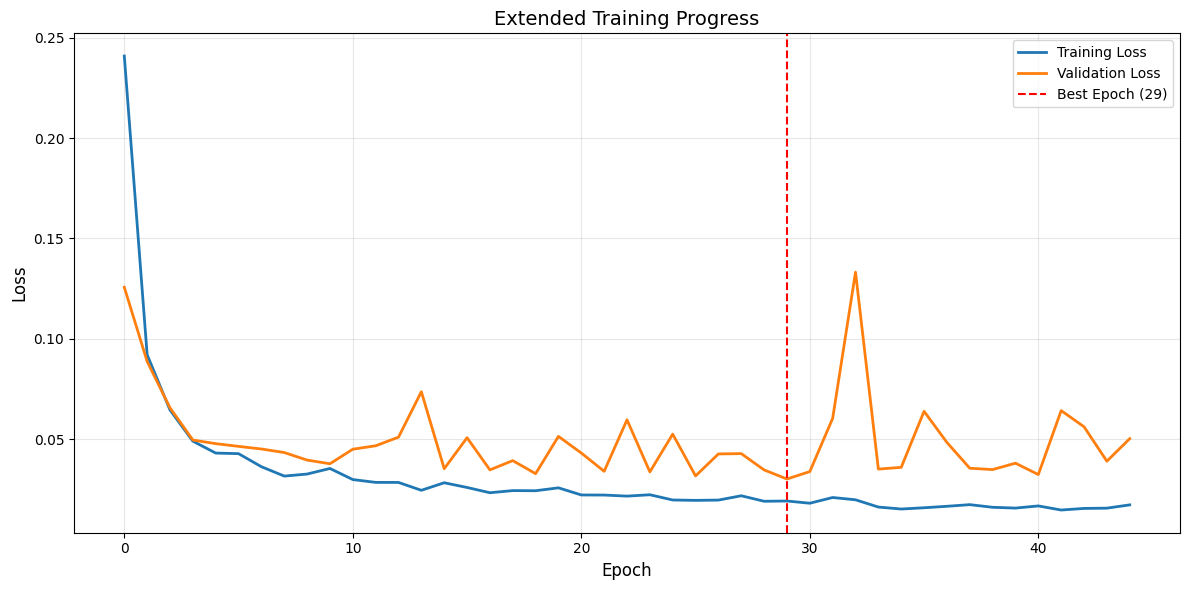

In [10]:

# ============================================================================
# CELL 11: Plot Training History  (skipped gracefully if loaded from checkpoint)
# ============================================================================
if history['train_loss'][0] is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    epochs = history['epoch']
    ax.plot(epochs, history['train_loss'], label='Training Loss',   linewidth=2)
    ax.plot(epochs, history['val_loss'],   label='Validation Loss', linewidth=2)
    ax.axvline(x=best_epoch, color='red', linestyle='--',
               label=f'Best Epoch ({best_epoch})')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss',  fontsize=12)
    ax.set_title('Extended Training Progress', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("(Training history not available — model was loaded from checkpoint)")


In [11]:
# ============================================================================
# CELL 12: Phase 3 — Test Set Evaluation
# ============================================================================
print("\n" + "="*70)
print("PHASE 3: Test Set Evaluation")
print("="*70)

trained_model.eval()
all_probs   = []
all_targets = []
loss_fn_test = ME0BCELoss(pos_weight=pos_weight).to_tensor_dict_module()

with torch.inference_mode():
    test_loss = 0
    for batch in tqdm(test_loader, desc='Test set evaluation'):
        batch = batch.to(device)
        out   = trained_model(batch)
        test_loss += loss_fn_test(out)['loss'].item()

        probs   = out['preds'].cpu()
        targets = batch['target'].cpu()
        mask    = batch['data_mask'].cpu()

        all_probs.append(probs[mask].numpy())
        all_targets.append(targets[mask].numpy())

test_loss /= len(test_loader)
print(f"\nTest Loss: {test_loss:.4f}")

all_probs   = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)



PHASE 3: Test Set Evaluation


Test set evaluation: 100%|██████████| 41/41 [00:03<00:00, 11.43it/s]


Test Loss: 0.0411



Generating ROC curve...


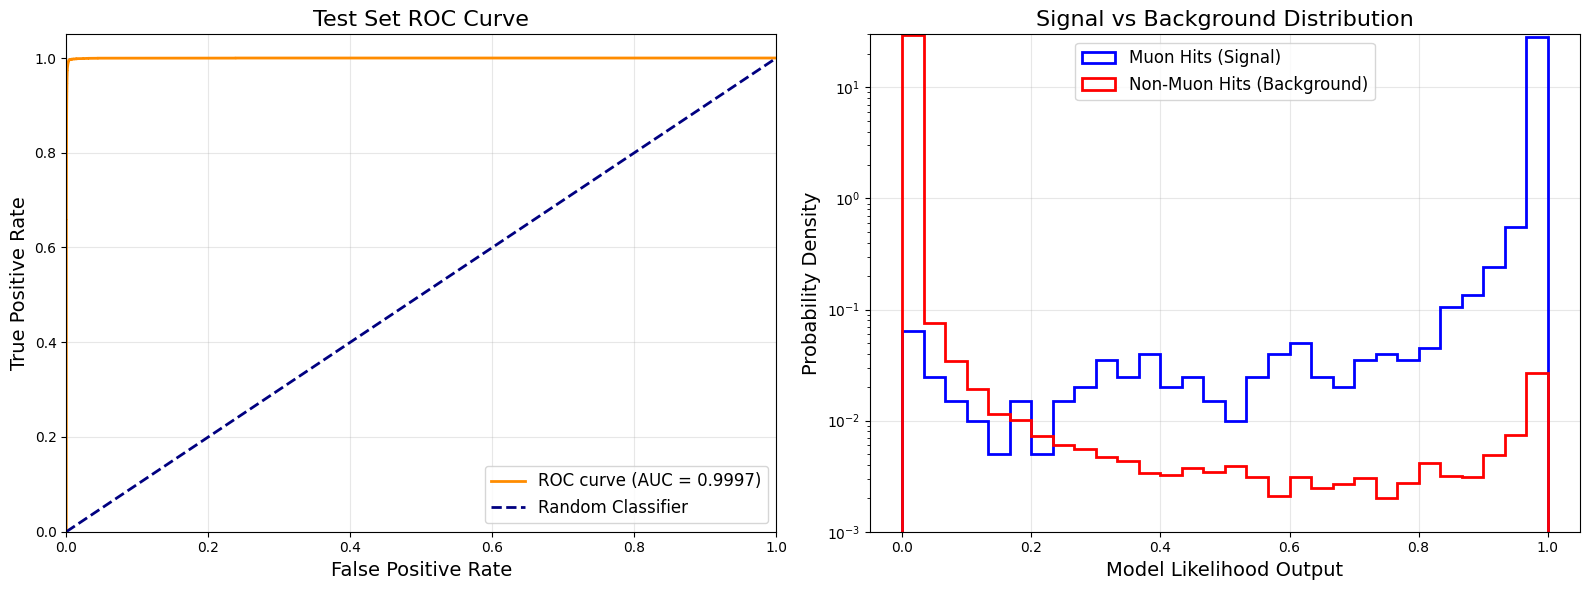

In [12]:
# ============================================================================
# CELL 13: ROC Curve + Score Distribution
# ============================================================================
print("\nGenerating ROC curve...")
fpr, tpr, thresholds = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

signal_probs     = all_probs[all_targets == 1]
background_probs = all_probs[all_targets == 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=14)
ax1.set_ylabel('True Positive Rate',  fontsize=14)
ax1.set_title('Test Set ROC Curve',   fontsize=16)
ax1.legend(loc="lower right", fontsize=12)
ax1.grid(alpha=0.3)

bins = np.linspace(0, 1, 31)
ax2.hist(signal_probs,     bins=bins, density=True, histtype='step',
         color='blue', linewidth=2, label='Muon Hits (Signal)')
ax2.hist(background_probs, bins=bins, density=True, histtype='step',
         color='red',  linewidth=2, label='Non-Muon Hits (Background)')
ax2.set_yscale('log')
ax2.set_xlabel('Model Likelihood Output', fontsize=14)
ax2.set_ylabel('Probability Density',     fontsize=14)
ax2.set_title('Signal vs Background Distribution', fontsize=16)
ax2.legend(fontsize=12)
ax2.grid(alpha=0.3)
ax2.set_ylim(1e-3, 3e1)

plt.tight_layout()
plt.show()


In [13]:
# ============================================================================
# CELL 14: TPR / FPR @ cutoff=0.5
# ============================================================================
def compute_tpr_fpr(groundtruth, likelihood, cutoff):
    mask    = groundtruth == 1
    tpr     = float((likelihood[mask]  >= cutoff).sum() / mask.sum())
    fpr_val = float((likelihood[~mask] >= cutoff).sum() / (~mask).sum())
    return tpr, fpr_val

tpr_50, fpr_50 = compute_tpr_fpr(all_targets, all_probs, 0.5)

print(f"\n{'='*70}")
print("FINAL RESULTS")
print(f"{'='*70}")
print(f"\nSignal Statistics:")
print(f"  Count:  {len(signal_probs):,}")
print(f"  Mean:   {signal_probs.mean():.4f}")
print(f"  Median: {np.median(signal_probs):.4f}")
print(f"\nBackground Statistics:")
print(f"  Count:  {len(background_probs):,}")
print(f"  Mean:   {background_probs.mean():.4f}")
print(f"  Median: {np.median(background_probs):.4f}")
print(f"\nModel Performance:")
print(f"  Test AUC:            {roc_auc:.4f}")
print(f"  Test Loss:           {test_loss:.4f}")
print(f"  TPR @ cutoff=0.5:    {tpr_50:.4f}")
print(f"  FPR @ cutoff=0.5:    {fpr_50:.4f}")
print(f"\nOptimal Hyperparameters:")
print(f"  Learning Rate:       {best_lr:.6f}")
print(f"  Optimal Epochs:      {best_epoch}")
print(f"  Best Val Loss:       {best_val_loss:.4f}")
print(f"{'='*70}")



FINAL RESULTS

Signal Statistics:
  Count:  6,033
  Mean:   0.9842
  Median: 0.9998

Background Statistics:
  Count:  446,813
  Mean:   0.0033
  Median: 0.0000

Model Performance:
  Test AUC:            0.9997
  Test Loss:           0.0411
  TPR @ cutoff=0.5:    0.9889
  FPR @ cutoff=0.5:    0.0025

Optimal Hyperparameters:
  Learning Rate:       0.003000
  Optimal Epochs:      29
  Best Val Loss:       0.0303


      FULL PIPELINE TIMING — IMAGE CONSTRUCTION + GPU PREDICTION


processing 35430 events: 100%|██████████| 1/1 [00:26<00:00, 26.32s/it]



[CONFIG]
  Dataset file:  ../data/step4_0.h5
  Device:        cuda
  Total events:  35,430
  Batch size:    128

[WARM-UP] Warming up GPU...
✓ Warm-up complete

[BENCHMARK] Processing entire dataset...


Processing batches: 100%|██████████| 277/277 [00:35<00:00,  7.74it/s]



✓ Done — 35,430 events processed

RESULTS

┌──────────────────────────────────────────────────────────────────────┐
│  PHASE                   │  TOTAL (s)  │  TOTAL (min) │  PER EVENT  │
├──────────────────────────────────────────────────────────────────────┤
│  Image Construction(CPU) │     25.606  │       0.427  │    0.723 ms │
│  H2D Transfer            │      1.755  │       0.029  │    0.050 ms │
│  Model Prediction (GPU)  │      7.667  │       0.128  │    0.216 ms │
│  Overhead                │      0.008  │       0.000  │    0.000 ms │
├──────────────────────────────────────────────────────────────────────┤
│  TOTAL                   │     35.037  │       0.584  │    0.989 ms │
└──────────────────────────────────────────────────────────────────────┘

  Image Construction: 73.1%  ← compare with GNN graph construction %
  Model Prediction:   21.9%  ← compare with GNN prediction %

📈 THROUGHPUT
  Events/second:  1,011.2
  Events/minute:  60,673.5
  Events/hour:    3,640,412

📊 IMA

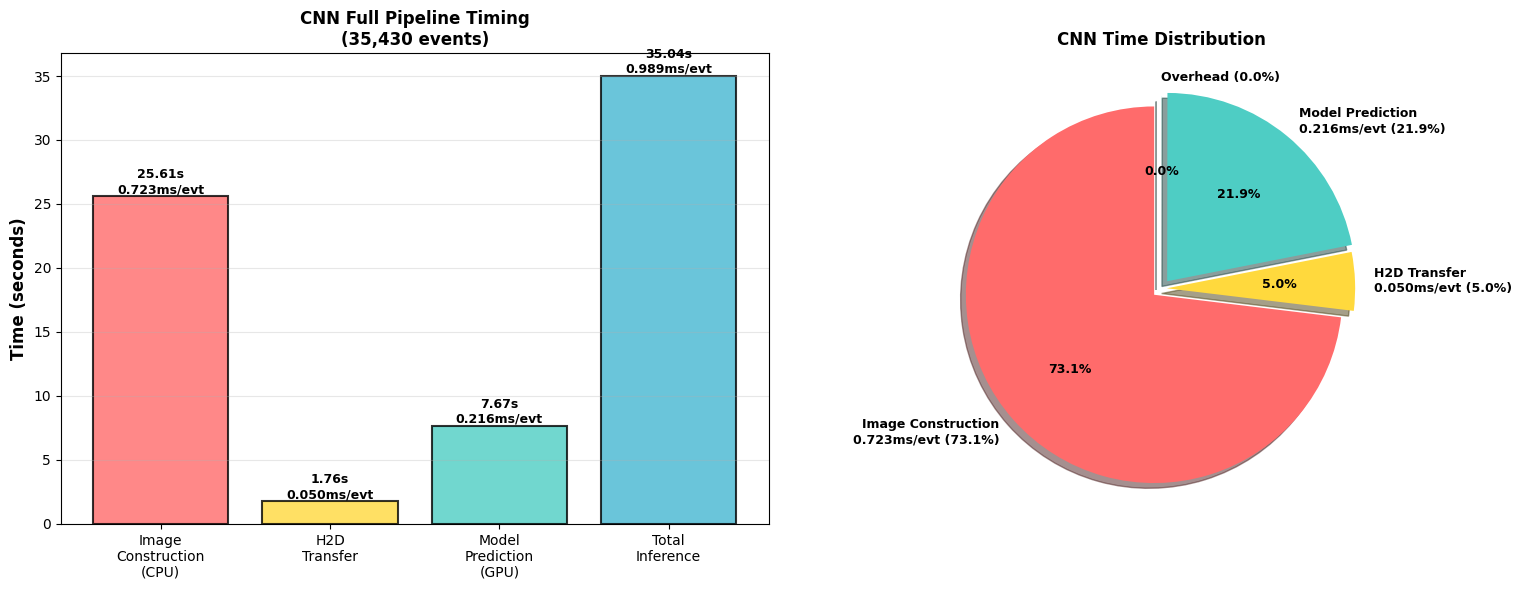

✓ Summary saved to 'cnn_full_pipeline_timing_summary.csv'

✅ ALL DONE


,Metric,Value
0,Total Events Processed,3.543000e+04
1,Batch Size,1.280000e+02
2,Image Construction — Total (s),2.560631e+01
3,Image Construction — Per Event (ms),7.227295e-01
4,H2D Transfer — Total (s),1.755464e+00
5,H2D Transfer — Per Event (ms),4.954738e-02
6,Model Prediction — Total (s),7.666965e+00
7,Model Prediction — Per Event (ms),2.163975e-01
8,Total Inference — Total (s),3.503670e+01
9,Total Inference — Per Event (ms),9.888991e-01


In [19]:
# ============================================================================
# CELL 15: Full Pipeline Timing — Image Construction + GPU Prediction
# ============================================================================
# Measures exactly what GNN measures:
#   CNN:  [image construction on CPU]  +  [H2D transfer + prediction on GPU]
#   GNN:  [graph construction on GPU]  +  [prediction on GPU]
# ============================================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

print("="*80)
print("      FULL PIPELINE TIMING — IMAGE CONSTRUCTION + GPU PREDICTION")
print("="*80)

if device.type != 'cuda':
    raise RuntimeError("⚠️  GPU required")

# Full dataset
full_dataset = ME0DigiImageDataset(
    file=DATA_FILE,
    features={
        'cls': {'min': 1, 'max': 384},
        'bx':  {'min': -3, 'max': 3},
    },
    get_central_bx=True,
)
total_events = len(full_dataset)
BATCH_SIZE   = 128

print(f"\n[CONFIG]")
print(f"  Dataset file:  {DATA_FILE}")
print(f"  Device:        {device}")
print(f"  Total events:  {total_events:,}")
print(f"  Batch size:    {BATCH_SIZE}\n")

# ===== Warm-up GPU =====
print("[WARM-UP] Warming up GPU...")
trained_model.eval()
warmup_items = [full_dataset[i] for i in range(BATCH_SIZE)]
warmup_batch = full_dataset.collate(warmup_items).to(device)
with torch.inference_mode():
    _ = trained_model(warmup_batch)
torch.cuda.synchronize()
del warmup_batch, warmup_items
print("✓ Warm-up complete\n")

# ===== Timed Benchmark =====
print("[BENCHMARK] Processing entire dataset...")
print("="*80)

total_image_construction_time = 0.0   # CPU: dataset[i] x128 + collate
total_h2d_time                = 0.0   # GPU: .to(device)
total_prediction_time         = 0.0   # GPU: model forward
total_inference_time          = 0.0   # end-to-end per batch
total_hits                    = 0
total_cells                   = 0
events_processed              = 0

# Build index batches manually so we can time construction separately
index_batches = [
    list(range(i, min(i + BATCH_SIZE, total_events)))
    for i in range(0, total_events, BATCH_SIZE)
]

trained_model.eval()

with torch.inference_mode():
    for idx_batch in tqdm(index_batches, desc="Processing batches"):

        # === TOTAL START ===
        t_total = time.perf_counter()

        # --- Phase 1: Image Construction (CPU) ---
        # dataset.__getitem__ reads HDF5 + builds image tensor for each event
        # then collate stacks them into a batch TensorDict
        t_img = time.perf_counter()
        items      = [full_dataset[i] for i in idx_batch]   # HDF5 read + image build
        cpu_batch  = full_dataset.collate(items)             # stack into TensorDict
        total_image_construction_time += time.perf_counter() - t_img

        # --- Phase 2: H2D Transfer (CPU RAM → GPU VRAM) ---
        t_h2d     = time.perf_counter()
        gpu_batch = cpu_batch.to(device)
        torch.cuda.synchronize()
        total_h2d_time += time.perf_counter() - t_h2d

        # --- Phase 3: Model Prediction (GPU) ---
        t_pred = time.perf_counter()
        out    = trained_model(gpu_batch)
        torch.cuda.synchronize()
        total_prediction_time += time.perf_counter() - t_pred

        # === TOTAL END ===
        total_inference_time += time.perf_counter() - t_total

        mask              = gpu_batch['data_mask']
        total_hits       += int(mask.sum().item())
        total_cells      += int(mask.numel())
        events_processed += len(idx_batch)

        del cpu_batch, gpu_batch, items

torch.cuda.empty_cache()
print(f"\n✓ Done — {events_processed:,} events processed\n")

# ===== Derived metrics =====
img_percent        = total_image_construction_time / total_inference_time * 100
h2d_percent        = total_h2d_time                / total_inference_time * 100
prediction_percent = total_prediction_time          / total_inference_time * 100
overhead_time      = total_inference_time - (total_image_construction_time +
                                             total_h2d_time + total_prediction_time)
overhead_percent   = overhead_time / total_inference_time * 100

per_event_img  = total_image_construction_time * 1000 / events_processed
per_event_h2d  = total_h2d_time                * 1000 / events_processed
per_event_pred = total_prediction_time         * 1000 / events_processed
per_event_tot  = total_inference_time          * 1000 / events_processed

throughput_per_sec  = events_processed / total_inference_time
throughput_per_min  = throughput_per_sec * 60
throughput_per_hour = throughput_per_sec * 3600

avg_hits    = total_hits  / events_processed
avg_cells   = total_cells / events_processed
hit_density = (total_hits / total_cells * 100) if total_cells > 0 else 0

# ===== Print results =====
print("="*80)
print("RESULTS")
print("="*80)
print(f"""
┌──────────────────────────────────────────────────────────────────────┐
│  PHASE                   │  TOTAL (s)  │  TOTAL (min) │  PER EVENT  │
├──────────────────────────────────────────────────────────────────────┤
│  Image Construction(CPU) │  {total_image_construction_time:>9.3f}  │  {total_image_construction_time/60:>10.3f}  │  {per_event_img:>7.3f} ms │
│  H2D Transfer            │  {total_h2d_time:>9.3f}  │  {total_h2d_time/60:>10.3f}  │  {per_event_h2d:>7.3f} ms │
│  Model Prediction (GPU)  │  {total_prediction_time:>9.3f}  │  {total_prediction_time/60:>10.3f}  │  {per_event_pred:>7.3f} ms │
│  Overhead                │  {overhead_time:>9.3f}  │  {overhead_time/60:>10.3f}  │  {overhead_time*1000/events_processed:>7.3f} ms │
├──────────────────────────────────────────────────────────────────────┤
│  TOTAL                   │  {total_inference_time:>9.3f}  │  {total_inference_time/60:>10.3f}  │  {per_event_tot:>7.3f} ms │
└──────────────────────────────────────────────────────────────────────┘
""")
print(f"  Image Construction: {img_percent:.1f}%  ← compare with GNN graph construction %")
print(f"  Model Prediction:   {prediction_percent:.1f}%  ← compare with GNN prediction %")

print(f"\n{'='*80}")
print("📈 THROUGHPUT")
print(f"{'='*80}")
print(f"  Events/second:  {throughput_per_sec:,.1f}")
print(f"  Events/minute:  {throughput_per_min:,.1f}")
print(f"  Events/hour:    {throughput_per_hour:,.0f}")

print(f"\n{'='*80}")
print("📊 IMAGE STATISTICS")
print(f"{'='*80}")
print(f"  Avg active hits per event:  {avg_hits:.1f}")
print(f"  Avg image cells per event:  {avg_cells:.1f}")
print(f"  Avg hit density:            {hit_density:.2f}%")

# ===== Visualization =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1    = axes[0]
labels = ['Image\nConstruction\n(CPU)',
          'H2D\nTransfer',
          'Model\nPrediction\n(GPU)',
          'Total\nInference']
times  = [total_image_construction_time, total_h2d_time,
          total_prediction_time, total_inference_time]
colors = ['#FF6B6B', '#FFD93D', '#4ECDC4', '#45B7D1']
bars   = ax1.bar(labels, times, color=colors, alpha=0.8,
                 edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Time (seconds)', fontsize=12, weight='bold')
ax1.set_title(f'CNN Full Pipeline Timing\n({events_processed:,} events)',
              fontsize=12, weight='bold')
ax1.grid(alpha=0.3, axis='y')
for bar, t, ms in zip(bars,
                      times,
                      [per_event_img, per_event_h2d,
                       per_event_pred, per_event_tot]):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{t:.2f}s\n{ms:.3f}ms/evt',
             ha='center', va='bottom', fontsize=9, weight='bold')

ax2       = axes[1]
pie_sizes = [total_image_construction_time, total_h2d_time,
             total_prediction_time, overhead_time]
pie_lbls  = [f'Image Construction\n{per_event_img:.3f}ms/evt ({img_percent:.1f}%)',
             f'H2D Transfer\n{per_event_h2d:.3f}ms/evt ({h2d_percent:.1f}%)',
             f'Model Prediction\n{per_event_pred:.3f}ms/evt ({prediction_percent:.1f}%)',
             f'Overhead ({overhead_percent:.1f}%)']
ax2.pie(pie_sizes, explode=(0.05, 0.03, 0.05, 0.02), labels=pie_lbls,
        colors=['#FF6B6B', '#FFD93D', '#4ECDC4', '#95E1D3'],
        autopct='%1.1f%%', shadow=True, startangle=90,
        textprops={'fontsize': 9, 'weight': 'bold'})
ax2.set_title('CNN Time Distribution', fontsize=12, weight='bold')

plt.tight_layout()
plt.savefig('cnn_full_pipeline_timing.png', dpi=300, bbox_inches='tight')
print("\n✓ Plot saved as 'cnn_full_pipeline_timing.png'")
plt.show()

# ===== Save CSV =====
df_summary = pd.DataFrame({
    'Metric': [
        'Total Events Processed', 'Batch Size',
        'Image Construction — Total (s)',  'Image Construction — Per Event (ms)',
        'H2D Transfer — Total (s)',        'H2D Transfer — Per Event (ms)',
        'Model Prediction — Total (s)',    'Model Prediction — Per Event (ms)',
        'Total Inference — Total (s)',     'Total Inference — Per Event (ms)',
        'Image Construction %', 'H2D Transfer %',
        'Model Prediction %',   'Overhead %',
        'Throughput (events/s)', 'Throughput (events/min)', 'Throughput (events/hr)',
        'Avg Active Hits per Event', 'Avg Image Cells per Event', 'Hit Density (%)',
    ],
    'Value': [
        events_processed, BATCH_SIZE,
        total_image_construction_time, per_event_img,
        total_h2d_time,                per_event_h2d,
        total_prediction_time,         per_event_pred,
        total_inference_time,          per_event_tot,
        img_percent, h2d_percent, prediction_percent, overhead_percent,
        throughput_per_sec, throughput_per_min, throughput_per_hour,
        avg_hits, avg_cells, hit_density,
    ]
})
df_summary.to_csv('cnn_full_pipeline_timing_summary.csv', index=False)
print("✓ Summary saved to 'cnn_full_pipeline_timing_summary.csv'")

print("\n" + "="*80)
print("✅ ALL DONE")
print("="*80)
display(df_summary)

                    TOTAL TIME FOR ENTIRE DATASET (CNN)
               (All 35,430 Events - Cumulative Times)

[CONFIG]
  Dataset file: ../data/step4_0.h5
  Device: cuda
  Batch size: 128
  Measuring TOTAL time for entire dataset



processing 35430 events: 100%|██████████| 1/1 [00:25<00:00, 25.53s/it]


[INFO] Total events: 35,430
[INFO] Total batches: 277
[INFO] Processing entire dataset...

[WARM-UP] Initializing GPU...
✓ Warm-up complete

PROCESSING ENTIRE DATASET



Processing all events: 100%|██████████| 277/277 [00:27<00:00, 10.15it/s]



✓ Processing complete!

TOTAL TIME FOR ENTIRE DATASET (CNN)
(35,430 events)

1️⃣  IMAGE CONSTRUCTION TIME — CPU (Entire Dataset)

  Total time:        17.612 seconds
  Total time:        0.294 minutes
  Total time:        0.0049 hours
  Average per event: 0.497 ms

2️⃣  H2D TRANSFER TIME — CPU→GPU (Entire Dataset)

  Total time:        1.587 seconds
  Total time:        0.026 minutes
  Total time:        0.0004 hours
  Average per event: 0.045 ms

3️⃣  MODEL PREDICTION TIME — GPU (Entire Dataset)

  Total time:        7.541 seconds
  Total time:        0.126 minutes
  Total time:        0.0021 hours
  Average per event: 0.213 ms

4️⃣  TOTAL INFERENCE TIME (Entire Dataset)

  Total time:        26.748 seconds
  Total time:        0.446 minutes
  Total time:        0.0074 hours
  Average per event: 0.755 ms

📊 TIME BREAKDOWN

  Component                      Time (sec)      Time (min)      Percentage  
  ---------------------------------------------------------------------------
  Image

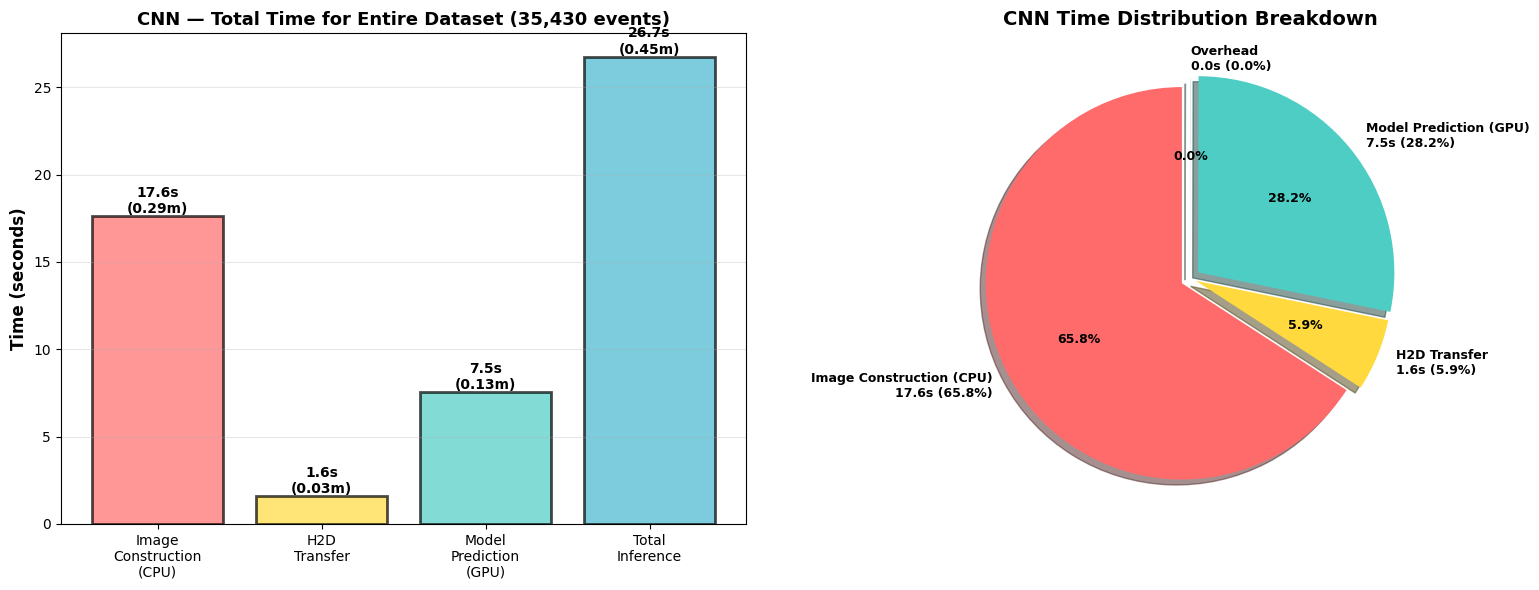


💾 SAVING RESULTS
✓ Summary saved to 'cnn_total_dataset_time_summary.csv'

✅ FINAL SUMMARY (CNN)

TOTAL TIME FOR ENTIRE DATASET (35,430 events):

1️⃣  IMAGE CONSTRUCTION (CPU):
    17.61 seconds = 0.29 minutes
    (65.8% of total time)

2️⃣  H2D TRANSFER (CPU → GPU):
    1.59 seconds = 0.03 minutes
    (5.9% of total time)

3️⃣  MODEL PREDICTION (GPU):
    7.54 seconds = 0.13 minutes
    (28.2% of total time)

4️⃣  TOTAL INFERENCE TIME:
    26.75 seconds = 0.45 minutes

THROUGHPUT:
    1324.6 events/second
    79475.7 events/minute
    4768543 events/hour

PROCESSED:
    3,062,601 total hits
    653,045,760 total image cells
    0.47% average hit density

✅ COMPLETE

📊 Summary Table:



,Metric,Value
0,Total Events,3.543000e+04
1,Image Construction Time (seconds),1.761172e+01
2,Image Construction Time (minutes),2.935286e-01
3,H2D Transfer Time (seconds),1.586771e+00
4,H2D Transfer Time (minutes),2.644619e-02
5,Model Prediction Time (seconds),7.540555e+00
6,Model Prediction Time (minutes),1.256759e-01
7,Total Inference Time (seconds),2.674779e+01
8,Total Inference Time (minutes),4.457966e-01
9,Image Construction Percentage,6.584363e+01


In [21]:
# ===== TOTAL TIME FOR ENTIRE DATASET (CNN) =====
print("="*80)
print(" "*20 + "TOTAL TIME FOR ENTIRE DATASET (CNN)")
print(" "*15 + "(All 35,430 Events - Cumulative Times)")
print("="*80)

import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# ===== Configuration =====
BATCH_SIZE = 128

print(f"\n[CONFIG]")
print(f"  Dataset file: {DATA_FILE}")
print(f"  Device: {device}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Measuring TOTAL time for entire dataset\n")

if device.type != 'cuda':
    print("⚠️  WARNING: GPU not detected. This code requires CUDA.")
    raise RuntimeError("GPU required")

# ===== Load Full Dataset =====
full_dataset = ME0DigiImageDataset(
    file=DATA_FILE,
    features={
        'cls': {'min': 1, 'max': 384},
        'bx':  {'min': -3, 'max': 3},
    },
    get_central_bx=True,
)
total_events = len(full_dataset)

# Build index batches manually (mirrors GNN event-by-event loop)
index_batches = [
    list(range(i, min(i + BATCH_SIZE, total_events)))
    for i in range(0, total_events, BATCH_SIZE)
]

print(f"[INFO] Total events: {total_events:,}")
print(f"[INFO] Total batches: {len(index_batches):,}")
print(f"[INFO] Processing entire dataset...\n")

# ===== Warm-up =====
print("[WARM-UP] Initializing GPU...")
trained_model.eval()
warmup_items = [full_dataset[i] for i in range(BATCH_SIZE)]
warmup_batch = full_dataset.collate(warmup_items).to(device)
with torch.inference_mode():
    _ = trained_model(warmup_batch)
torch.cuda.synchronize()
del warmup_batch, warmup_items
print("✓ Warm-up complete\n")

# ===== Initialize Accumulators =====
total_image_construction_time = 0.0
total_h2d_time                = 0.0
total_prediction_time         = 0.0
total_inference_time          = 0.0

total_hits  = 0
total_cells = 0

# ===== MEASURE ENTIRE DATASET =====
print("="*80)
print("PROCESSING ENTIRE DATASET")
print("="*80)
print()

trained_model.eval()

with torch.inference_mode():
    for idx_batch in tqdm(index_batches, desc="Processing all events"):

        # === START TOTAL TIME ===
        total_start = time.perf_counter()

        # === 1. IMAGE CONSTRUCTION (CPU) ===
        # Equivalent to GNN's build_graph_on_gpu()
        # Reads HDF5 + builds 3D image tensor for each event in batch
        img_start  = time.perf_counter()
        items      = [full_dataset[i] for i in idx_batch]
        cpu_batch  = full_dataset.collate(items)
        img_end    = time.perf_counter()
        total_image_construction_time += (img_end - img_start)

        # === 2. H2D TRANSFER (CPU RAM → GPU VRAM) ===
        h2d_start  = time.perf_counter()
        gpu_batch  = cpu_batch.to(device)
        torch.cuda.synchronize()
        h2d_end    = time.perf_counter()
        total_h2d_time += (h2d_end - h2d_start)

        # === 3. MODEL PREDICTION ===
        pred_start = time.perf_counter()
        out        = trained_model(gpu_batch)
        torch.cuda.synchronize()
        pred_end   = time.perf_counter()
        total_prediction_time += (pred_end - pred_start)

        # === END TOTAL TIME ===
        total_end = time.perf_counter()
        total_inference_time += (total_end - total_start)

        # Accumulate image statistics
        mask        = gpu_batch['data_mask']
        total_hits  += int(mask.sum().item())
        total_cells += int(mask.numel())

        del cpu_batch, gpu_batch, items

torch.cuda.empty_cache()
print("\n✓ Processing complete!\n")

# ===== RESULTS =====
print("="*80)
print("TOTAL TIME FOR ENTIRE DATASET (CNN)")
print(f"({total_events:,} events)")
print("="*80)

print("\n" + "="*80)
print("1️⃣  IMAGE CONSTRUCTION TIME — CPU (Entire Dataset)")
print("="*80)
print(f"\n  Total time:        {total_image_construction_time:.3f} seconds")
print(f"  Total time:        {total_image_construction_time/60:.3f} minutes")
print(f"  Total time:        {total_image_construction_time/3600:.4f} hours")
print(f"  Average per event: {total_image_construction_time*1000/total_events:.3f} ms")

print("\n" + "="*80)
print("2️⃣  H2D TRANSFER TIME — CPU→GPU (Entire Dataset)")
print("="*80)
print(f"\n  Total time:        {total_h2d_time:.3f} seconds")
print(f"  Total time:        {total_h2d_time/60:.3f} minutes")
print(f"  Total time:        {total_h2d_time/3600:.4f} hours")
print(f"  Average per event: {total_h2d_time*1000/total_events:.3f} ms")

print("\n" + "="*80)
print("3️⃣  MODEL PREDICTION TIME — GPU (Entire Dataset)")
print("="*80)
print(f"\n  Total time:        {total_prediction_time:.3f} seconds")
print(f"  Total time:        {total_prediction_time/60:.3f} minutes")
print(f"  Total time:        {total_prediction_time/3600:.4f} hours")
print(f"  Average per event: {total_prediction_time*1000/total_events:.3f} ms")

print("\n" + "="*80)
print("4️⃣  TOTAL INFERENCE TIME (Entire Dataset)")
print("="*80)
print(f"\n  Total time:        {total_inference_time:.3f} seconds")
print(f"  Total time:        {total_inference_time/60:.3f} minutes")
print(f"  Total time:        {total_inference_time/3600:.4f} hours")
print(f"  Average per event: {total_inference_time*1000/total_events:.3f} ms")

# ===== BREAKDOWN =====
print("\n" + "="*80)
print("📊 TIME BREAKDOWN")
print("="*80)

img_percent        = (total_image_construction_time / total_inference_time) * 100
h2d_percent        = (total_h2d_time                / total_inference_time) * 100
prediction_percent = (total_prediction_time          / total_inference_time) * 100
overhead_time      = total_inference_time - (total_image_construction_time +
                                             total_h2d_time + total_prediction_time)
overhead_percent   = (overhead_time / total_inference_time) * 100

print(f"\n  {'Component':<30} {'Time (sec)':<15} {'Time (min)':<15} {'Percentage':<12}")
print(f"  {'-'*75}")
print(f"  {'Image Construction (CPU)':<30} {total_image_construction_time:>13.3f}   {total_image_construction_time/60:>13.3f}   {img_percent:>10.1f}%")
print(f"  {'H2D Transfer (CPU→GPU)':<30} {total_h2d_time:>13.3f}   {total_h2d_time/60:>13.3f}   {h2d_percent:>10.1f}%")
print(f"  {'Model Prediction (GPU)':<30} {total_prediction_time:>13.3f}   {total_prediction_time/60:>13.3f}   {prediction_percent:>10.1f}%")
print(f"  {'Overhead':<30} {overhead_time:>13.3f}   {overhead_time/60:>13.3f}   {overhead_percent:>10.1f}%")
print(f"  {'-'*75}")
print(f"  {'TOTAL':<30} {total_inference_time:>13.3f}   {total_inference_time/60:>13.3f}   {'100.0%':>10}")

# ===== THROUGHPUT =====
print("\n" + "="*80)
print("📈 THROUGHPUT")
print("="*80)

throughput_per_sec  = total_events / total_inference_time
throughput_per_min  = throughput_per_sec * 60
throughput_per_hour = throughput_per_sec * 3600

print(f"\n  Events per second:     {throughput_per_sec:.1f}")
print(f"  Events per minute:     {throughput_per_min:.1f}")
print(f"  Events per hour:       {throughput_per_hour:.1f}")

# ===== IMAGE STATISTICS =====
print("\n" + "="*80)
print("📊 IMAGE STATISTICS (Entire Dataset)")
print("="*80)

avg_hits    = total_hits  / total_events
avg_cells   = total_cells / total_events
hit_density = (total_hits / total_cells * 100) if total_cells > 0 else 0

print(f"\n  Total hits processed:      {total_hits:,}")
print(f"  Total image cells:         {total_cells:,}")
print(f"  Average hits per event:    {avg_hits:.1f}")
print(f"  Average cells per image:   {avg_cells:.1f}")
print(f"  Average hit density:       {hit_density:.2f}%")

# ===== VISUALIZATION =====
print("\n" + "="*80)
print("📊 GENERATING VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart
ax1        = axes[0]
components = ['Image\nConstruction\n(CPU)', 'H2D\nTransfer',
              'Model\nPrediction\n(GPU)', 'Total\nInference']
times_sec  = [total_image_construction_time, total_h2d_time,
              total_prediction_time,         total_inference_time]
colors_bar = ['#FF6B6B', '#FFD93D', '#4ECDC4', '#45B7D1']

bars = ax1.bar(components, times_sec, color=colors_bar,
               alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Time (seconds)', fontsize=12, weight='bold')
ax1.set_title(f'CNN — Total Time for Entire Dataset ({total_events:,} events)',
              fontsize=13, weight='bold')
ax1.grid(alpha=0.3, axis='y')

for bar, t in zip(bars, times_sec):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{t:.1f}s\n({t/60:.2f}m)',
             ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 2: Pie chart
ax2        = axes[1]
sizes      = [total_image_construction_time, total_h2d_time,
              total_prediction_time,          overhead_time]
labels_pie = [
    f'Image Construction (CPU)\n{total_image_construction_time:.1f}s ({img_percent:.1f}%)',
    f'H2D Transfer\n{total_h2d_time:.1f}s ({h2d_percent:.1f}%)',
    f'Model Prediction (GPU)\n{total_prediction_time:.1f}s ({prediction_percent:.1f}%)',
    f'Overhead\n{overhead_time:.1f}s ({overhead_percent:.1f}%)',
]
colors_pie = ['#FF6B6B', '#FFD93D', '#4ECDC4', '#95E1D3']
explode    = (0.05, 0.03, 0.05, 0.02)

ax2.pie(sizes, explode=explode, labels=labels_pie, colors=colors_pie,
        autopct='%1.1f%%', shadow=True, startangle=90,
        textprops={'fontsize': 9, 'weight': 'bold'})
ax2.set_title('CNN Time Distribution Breakdown', fontsize=14, weight='bold')

plt.tight_layout()
plt.savefig('cnn_total_dataset_time.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved as 'cnn_total_dataset_time.png'")
plt.show()

# ===== SAVE RESULTS =====
print("\n" + "="*80)
print("💾 SAVING RESULTS")
print("="*80)

summary = {
    'Metric': [
        'Total Events',
        'Image Construction Time (seconds)',
        'Image Construction Time (minutes)',
        'H2D Transfer Time (seconds)',
        'H2D Transfer Time (minutes)',
        'Model Prediction Time (seconds)',
        'Model Prediction Time (minutes)',
        'Total Inference Time (seconds)',
        'Total Inference Time (minutes)',
        'Image Construction Percentage',
        'H2D Transfer Percentage',
        'Model Prediction Percentage',
        'Overhead Percentage',
        'Throughput (events/second)',
        'Throughput (events/minute)',
        'Total Hits Processed',
        'Total Image Cells',
        'Average Hits per Event',
        'Average Cells per Image',
        'Average Hit Density (%)',
    ],
    'Value': [
        total_events,
        total_image_construction_time,
        total_image_construction_time / 60,
        total_h2d_time,
        total_h2d_time / 60,
        total_prediction_time,
        total_prediction_time / 60,
        total_inference_time,
        total_inference_time / 60,
        img_percent,
        h2d_percent,
        prediction_percent,
        overhead_percent,
        throughput_per_sec,
        throughput_per_min,
        total_hits,
        total_cells,
        avg_hits,
        avg_cells,
        hit_density,
    ]
}

df_summary = pd.DataFrame(summary)
df_summary.to_csv('cnn_total_dataset_time_summary.csv', index=False)
print("✓ Summary saved to 'cnn_total_dataset_time_summary.csv'")

# ===== FINAL SUMMARY =====
print("\n" + "="*80)
print("✅ FINAL SUMMARY (CNN)")
print("="*80)

print(f"""
TOTAL TIME FOR ENTIRE DATASET ({total_events:,} events):

1️⃣  IMAGE CONSTRUCTION (CPU):
    {total_image_construction_time:.2f} seconds = {total_image_construction_time/60:.2f} minutes
    ({img_percent:.1f}% of total time)

2️⃣  H2D TRANSFER (CPU → GPU):
    {total_h2d_time:.2f} seconds = {total_h2d_time/60:.2f} minutes
    ({h2d_percent:.1f}% of total time)

3️⃣  MODEL PREDICTION (GPU):
    {total_prediction_time:.2f} seconds = {total_prediction_time/60:.2f} minutes
    ({prediction_percent:.1f}% of total time)

4️⃣  TOTAL INFERENCE TIME:
    {total_inference_time:.2f} seconds = {total_inference_time/60:.2f} minutes

THROUGHPUT:
    {throughput_per_sec:.1f} events/second
    {throughput_per_min:.1f} events/minute
    {throughput_per_hour:.0f} events/hour

PROCESSED:
    {total_hits:,} total hits
    {total_cells:,} total image cells
    {hit_density:.2f}% average hit density
""")

print("="*80)
print("✅ COMPLETE")
print("="*80)

print("\n📊 Summary Table:\n")
display(df_summary)